# Robustness checks

Sensitivity analyses for the three decisions most likely to swing the headline
finding from `02_main.ipynb` — **taxonomy granularity**, **confidence
threshold**, and **deduplication threshold**. Each section re-derives the
headline under a perturbation and reports how much it moves.

**The headline under test** (pooled over the four elections, framed rows only):
African press foregrounds *process* — the mechanics of voting — at **39.0%** vs.
**27.1%** for international press (**+11.9 pp**); international press foregrounds
*democracy* — democratic stakes — at **26.9%** vs. **16.5%** African
(**+10.4 pp**).

---

## Summary — which decisions are headline-load-bearing

Of the three decisions stress-tested, **only the taxonomy choice is
load-bearing.**

- **Confidence threshold — robust.** The between-origin gap holds at ~**+11 pp**
  (process) / ~**−10 pp** (democracy) from the all-framed headline all the way
  through an accepted-only gate at 0.80. Tightening the gate lowers the
  *absolute* level of every frame (the gate is not frame-neutral, per Decision
  Log #7) but is approximately *origin-neutral in the difference* — and the
  difference is what the headline reports.
- **Dedup threshold — robust.** Re-running dedup at MinHash Jaccard 0.7 / 0.9
  around the 0.8 production choice changes the kept-row count by ≤ **2%** on the
  probe, and the marginal rows split across origins in the same ~74/26
  proportion as the corpus — so they cannot move a between-origin gap.
- **Taxonomy granularity — load-bearing.** If *democracy* and *process* are
  merged into a single *governance* frame, the gap **collapses to +1.5 pp**:
  African and international press give governance near-identical *total*
  attention (55.6% vs. 54.1%); they diverge entirely in *how they split it*
  (mechanics vs. democratic stakes). The headline therefore depends on the
  6-frame taxonomy keeping these two frames apart — the choice defended in
  `04_pipeline_eval.ipynb`'s taxonomy decision block (merging lifts eval
  micro-F1 0.552 → 0.598 but erases the distinction the research question is
  about).

**Read the headline as:** *conditional on treating "process" and "democracy" as
distinct dimensions, African and international coverage split their governance
coverage in opposite directions* — a conclusion that is insensitive to the
confidence gate and the dedup threshold, but inseparable from that taxonomic
distinction.

## Setup

Load the production labels, fold the edge desks into International (matching the
headline attribution in `02_main.ipynb` §7), and confirm the baseline headline
reproduces before perturbing it.

In [1]:
"""Load production labels + reproduce the baseline headline."""
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("../src").resolve()))
from elections_frames import viz
from elections_frames.data import ELECTIONS

viz.set_style()

clf = pd.read_parquet("../data/processed/articles_classified.parquet")
# Headline attribution: edge desks fold into International (02_main §7, Decision 1).
clf["outlet_origin"] = clf["outlet_origin"].replace(
    {"Edge_BBC_Africa": "International", "Edge_RFI_Afrique": "International"}
)
ELECTION_ORDER = ["nigeria_2023", "kenya_2022", "senegal_2024", "south_africa_2024"]

shares, sizes = viz.frame_share_matrix(clf, "outlet_origin")
gap = (shares.loc["African"] - shares.loc["International"]) * 100
print("Baseline 6-frame headline (% of framed articles):")
print((shares * 100).round(1).to_string())
print("framed n:", {k: int(v) for k, v in sizes.items()})
print("\nAfrican - International (pp), sorted:")
print(gap.sort_values(ascending=False).round(1).to_string())


Baseline 6-frame headline (% of framed articles):
pred_primary   security  economy  democracy  identity  process  corruption
outlet_origin                                                             
African            17.0     12.4       16.5       7.1     39.0         8.0
International      14.2     16.5       26.9       8.1     27.1         7.1
framed n: {'African': 15614, 'International': 19380}

African - International (pp), sorted:
pred_primary
process       11.9
security       2.8
corruption     0.9
identity      -1.0
economy       -4.2
democracy    -10.4


## 1. Taxonomy granularity sensitivity

Re-aggregate the headline under a coarser taxonomy and ask whether the finding
survives.

**Which perturbation?** The taxonomy decision block in `04_pipeline_eval.ipynb`
identified *democracy ↔ process* as the dominant residual confusion and carried
the **5-frame collapse `democracy + process → governance`** as the documented
alternative (Decision Log #6). That is the perturbation here: it merges existing
labels, so it is a cheap re-aggregation of the production data — no
reclassification needed.

**Why not a 7-frame split?** The skeleton mentioned a 7-frame variant, but
*splitting* a frame (e.g. carving `process` into `logistics` vs. `results`) is
not a re-aggregation — it needs fresh labels against a new codebook, i.e. a
re-run of the LLM classifier and ideally a re-label of the gold set. That is out
of scope for a sensitivity pass and is noted as a future check. The defensible
taxonomy stress-test on the existing labels is the collapse, which directly
targets the frames the headline rests on.

5-frame headline (% of framed articles):
pred_primary   security  economy  governance  identity  corruption
outlet_origin                                                     
African            17.0     12.4        55.6       7.1         8.0
International      14.2     16.5        54.1       8.1         7.1

African - International (pp), 5-frame:
pred_primary
security      2.8
governance    1.5
corruption    0.9
identity     -1.0
economy      -4.2

governance gap = +1.5 pp  (vs 6-frame: process +11.9 + democracy -10.4)

Per-election: do the 6-frame component gaps cancel inside governance?
                           proc_gap  dem_gap  gov_gap  gov_share_afr  gov_share_intl
election                                                                            
Nigeria 2023 presidential       4.4     -1.5      2.9           53.0            50.0
Kenya 2022 general              9.5     -2.0      7.4           64.0            57.0
Senegal 2024 presidential      -1.9     10.3      8.3           

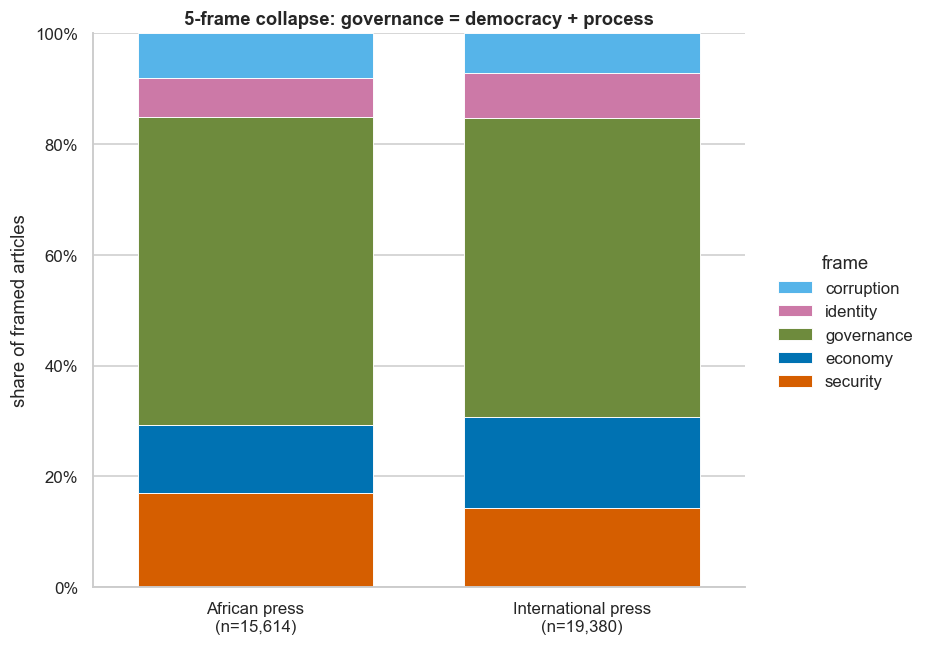

In [2]:
"""5-frame collapse: democracy + process -> governance. Pooled + per-election."""
FRAMES5 = ["security", "economy", "governance", "identity", "corruption"]
# governance = democracy (green) + process (orange) merged; give it its own swatch.
viz.FRAME_COLORS["governance"] = "#6E8B3D"  # olive — visually "between" the two

clf5 = clf.copy()
clf5["pred_primary"] = clf5["pred_primary"].replace(
    {"democracy": "governance", "process": "governance"}
)

sh5, sz5 = viz.frame_share_matrix(clf5, "outlet_origin", frames=FRAMES5)
gap5 = (sh5.loc["African"] - sh5.loc["International"]) * 100
print("5-frame headline (% of framed articles):")
print((sh5 * 100).round(1).to_string())
print("\nAfrican - International (pp), 5-frame:")
print(gap5.sort_values(ascending=False).round(1).to_string())
print(
    f"\ngovernance gap = {gap5['governance']:+.1f} pp"
    f"  (vs 6-frame: process {gap['process']:+.1f} + democracy {gap['democracy']:+.1f})"
)

print("\nPer-election: do the 6-frame component gaps cancel inside governance?")
rows = []
for k in ELECTION_ORDER:
    s6, _ = viz.frame_share_matrix(clf[clf.election == k], "outlet_origin")
    s5, z5 = viz.frame_share_matrix(clf5[clf5.election == k], "outlet_origin", frames=FRAMES5)
    if {"African", "International"} <= set(s6.index):
        rows.append({
            "election": ELECTIONS[k].name,
            "proc_gap": round((s6.loc["African", "process"] - s6.loc["International", "process"]) * 100, 1),
            "dem_gap": round((s6.loc["African", "democracy"] - s6.loc["International", "democracy"]) * 100, 1),
            "gov_gap": round((s5.loc["African", "governance"] - s5.loc["International", "governance"]) * 100, 1),
            "gov_share_afr": round(s5.loc["African", "governance"] * 100, 0),
            "gov_share_intl": round(s5.loc["International", "governance"] * 100, 0),
        })
print(pd.DataFrame(rows).set_index("election").to_string())

fig = viz.stacked_frame_bar(
    clf5, by="outlet_origin", frames=FRAMES5,
    title="5-frame collapse: governance = democracy + process",
)
viz.save_figure(fig, "robust_taxonomy_5frame")
plt.show()


**What the analysis shows.** The headline **does not survive** the collapse.
Pooled, governance takes **55.6%** of African framed articles and **54.1%** of
international — a gap of **+1.5 pp**, down from the +11.9 pp (process) and
−10.4 pp (democracy) it is built from. The two large opposing gaps cancel almost
exactly inside governance: African and international press devote *the same total
share* to governance coverage; they differ in **how they split it** — African
toward mechanics (process), international toward democratic stakes (democracy).

Per election, the cancellation is near-total where the two components are
balanced — **South Africa +0.8 pp** (process +7.4 / democracy −6.7),
**Nigeria +2.9 pp** — and partial where one component dominates: **Kenya +7.4**
(process-driven) and **Senegal +8.3** (democracy-driven, the constitutional-crisis
story). The residual is never the original double-digit gap.

This is the intended reading of Decision Log #6: the 5-frame taxonomy is more
*learnable* (merging lifts eval micro-F1 0.552 → 0.598) but it **erases the
finding**, because the finding *is* the democracy-vs-process split. The headline
is conditional on the 6-frame choice to keep them distinct — and that choice is
defended on substantive, not fit, grounds in `04_pipeline_eval.ipynb`.

## 2. Confidence threshold sensitivity

The headline uses **all framed rows**; the 0.75 confidence threshold is stored as
an `accepted` flag, not applied (Decision Log #7 / #8) because gating shifts the
*absolute* frame mix (+15 pp democracy / −10 pp process). The question for
robustness is different: does gating change the **between-origin gap** — the
quantity the headline actually reports? Re-run the headline accepted-only at
**0.70 / 0.75 / 0.80** and compare to all-framed.

Headline by confidence gate (% framed; gap = African - International):
            n_afr  n_intl  frame_n   ret%  proc_afr  proc_intl  proc_gap  dem_afr  dem_intl  dem_gap
gate                                                                                                
all-framed  15614   19380    34994  100.0      39.0       27.1      11.9     16.5      26.9    -10.4
acc>=0.70   11637   14020    25657   73.0      37.3       25.5      11.8     14.2      25.4    -11.2
acc>=0.75    6580    7369    13949   40.0      34.0       21.8      12.2     10.7      20.5     -9.8
acc>=0.80    4431    4912     9343   27.0      29.5       19.1      10.5      8.8      17.7     -9.0


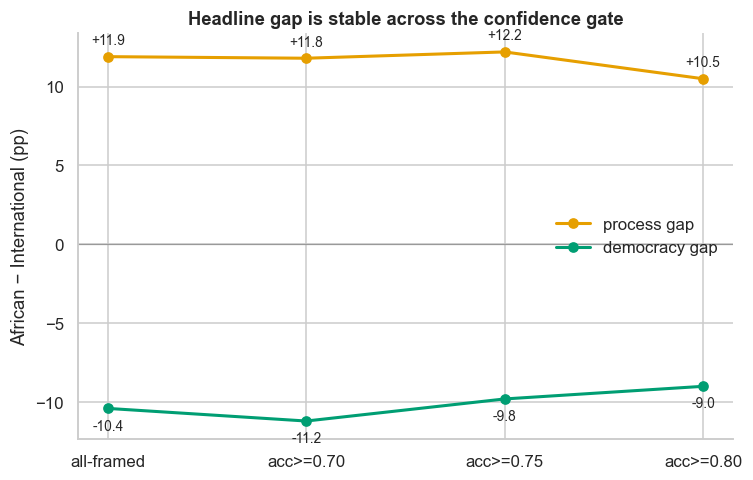

In [3]:
"""Headline gap at all-framed vs accepted-only thresholds."""
fr = viz.framed(clf)
gates = [("all-framed", fr)] + [(f"acc>={t:.2f}", fr[fr.pred_confidence >= t]) for t in (0.70, 0.75, 0.80)]

rows = []
for label, sub in gates:
    sh, sz = viz.frame_share_matrix(sub, "outlet_origin")
    pa, pi = sh.loc["African", "process"] * 100, sh.loc["International", "process"] * 100
    da, di = sh.loc["African", "democracy"] * 100, sh.loc["International", "democracy"] * 100
    rows.append({
        "gate": label, "n_afr": int(sz["African"]), "n_intl": int(sz["International"]),
        "frame_n": int(sz.sum()), "ret%": round(100 * sz.sum() / len(fr), 0),
        "proc_afr": round(pa, 1), "proc_intl": round(pi, 1), "proc_gap": round(pa - pi, 1),
        "dem_afr": round(da, 1), "dem_intl": round(di, 1), "dem_gap": round(da - di, 1),
    })
sweep = pd.DataFrame(rows).set_index("gate")
print("Headline by confidence gate (% framed; gap = African - International):")
print(sweep.to_string())

x = np.arange(len(sweep))
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.axhline(0, color="0.6", lw=0.8)
ax.plot(x, sweep["proc_gap"], "o-", color=viz.FRAME_COLORS["process"], lw=2, label="process gap")
ax.plot(x, sweep["dem_gap"], "o-", color=viz.FRAME_COLORS["democracy"], lw=2, label="democracy gap")
for i, (pg, dg) in enumerate(zip(sweep["proc_gap"], sweep["dem_gap"])):
    ax.annotate(f"{pg:+.1f}", (i, pg), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
    ax.annotate(f"{dg:+.1f}", (i, dg), textcoords="offset points", xytext=(0, -14), ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(sweep.index)
ax.set_ylabel("African − International (pp)")
ax.set_title("Headline gap is stable across the confidence gate")
ax.legend(frameon=False, loc="center right")
fig.tight_layout()
viz.save_figure(fig, "robust_threshold_gaps")
plt.show()


**What the analysis shows.** The between-origin gap is **robust to the gate.**
The process gap stays in **[+10.5, +12.2] pp** and the democracy gap in
**[−11.2, −9.0] pp** across all-framed and every accepted-only threshold;
direction and rank order never change. What *does* move is the absolute level —
African process falls 39.0 → 29.5% as the gate tightens to 0.80 — exactly the
non-frame-neutrality Decision Log #7 flagged. But that shift lands on **both
origins together**, so it cancels in the difference: the gate is approximately
*origin-neutral* even though it is not *frame-neutral*.

Two upstream choices are vindicated. Session 7's decision to headline **all
framed rows** preserves the absolute levels (which a reader cares about) without
risking the gap; and Session 6's decision to keep the threshold as a **flag, not
a filter** loses nothing on the headline. The only real cost of gating is
coverage: accepted@0.75 keeps 40% of framed rows, accepted@0.80 only 27% — so
gating would buy no robustness while discarding most of the sample.

## 3. Deduplication threshold sensitivity

Production deduped at **MinHash Jaccard 0.8** (Decision 3). Re-running the full
4.8 h cleaning pass at 0.7 and 0.9 would be the exhaustive check; Session 3
already measured ≤ 3% movement across 0.7–0.95 there. This section confirms that
at probe scale and — the part that actually matters for the *headline* — checks
whether the rows whose fate depends on the threshold are **origin-balanced**. If
the marginal rows split across origins in the same proportion as the corpus, the
threshold cannot move a between-origin gap, regardless of how many rows it
touches.

*(Probe-set estimate, per the session scope — not a full-corpus re-run. The
classified corpus is already deduped at 0.8 and cannot be un-deduped, so the
headline impact is bounded by the marginal rows' origin mix rather than
recomputed directly.)*

Relevance-filtered probe: 692 rows  ({'International': 513, 'African': 179})



MinHash threshold sweep (probe):
 threshold  n_in  n_kept  merged  pct_kept vs_0.8
       0.7   692     583     109      84.2  -1.9%
       0.8   692     594      98      85.8  +0.0%
       0.9   692     598      94      86.4  +0.7%

Swing set (kept@0.9 but merged-away@0.7): 15 of 692 rows (2.2%)
  swing-set origin mix: {'International': '11 (73%)', 'African': '4 (27%)'}
  corpus    origin mix: {'International': '513 (74%)', 'African': '179 (26%)'}


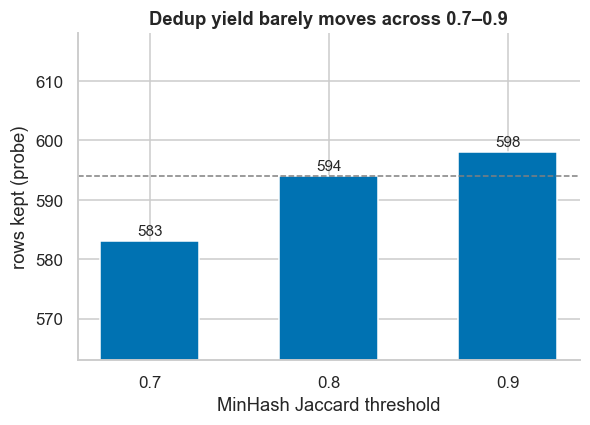

In [4]:
"""Dedup sweep on the relevance-filtered probe + origin mix of the swing set."""
from elections_frames.cleaning import (
    build_text_snippet, canonicalize_url, collapse_edge_to_international,
    deduplicate, filter_relevant,
)

probe = pd.read_parquet("../.cache/probe_attributed.parquet")
filtered = []
for k in ELECTIONS:
    kept, _ = filter_relevant(probe[probe.election == k], ELECTIONS[k], method="hybrid")
    filtered.append(kept)
rel = pd.concat(filtered, ignore_index=True)
rel["text_snippet"] = rel.apply(build_text_snippet, axis=1)
rel["canon_url"] = rel.DocumentIdentifier.fillna("").apply(canonicalize_url)
rel["origin_folded"] = collapse_edge_to_international(rel["outlet_origin"])
print(f"Relevance-filtered probe: {len(rel):,} rows  "
      f"({rel.origin_folded.value_counts().to_dict()})")

sweep, kept = [], {}
for thr in (0.7, 0.8, 0.9):
    out, c = deduplicate(rel.copy(), threshold=thr)
    kept[thr] = out
    sweep.append({"threshold": thr, "n_in": c["n_in"], "n_kept": c["n_after_text_dedup"],
                  "merged": c["n_text_duplicates"],
                  "pct_kept": round(100 * c["n_after_text_dedup"] / c["n_in"], 1)})
sw = pd.DataFrame(sweep)
base = int(sw.loc[sw.threshold == 0.8, "n_kept"].iloc[0])
sw["vs_0.8"] = sw["n_kept"].apply(lambda n: f"{(n - base) / base:+.1%}")
print("\nMinHash threshold sweep (probe):")
print(sw.to_string(index=False))

# Swing set: rows whose survival flips between the tight (0.7) and loose (0.9) ends.
swing = set(kept[0.9].canon_url) - set(kept[0.7].canon_url)
sw_rows = rel[rel.canon_url.isin(swing)].drop_duplicates("canon_url")
corpus = rel.drop_duplicates("canon_url")
def _mix(s):
    vc = s.value_counts()
    return {o: f"{vc.get(o, 0)} ({vc.get(o, 0) / vc.sum():.0%})" for o in ("International", "African")}
print(f"\nSwing set (kept@0.9 but merged-away@0.7): {len(sw_rows)} of {len(corpus)} rows "
      f"({len(sw_rows) / len(corpus):.1%})")
print("  swing-set origin mix:", _mix(sw_rows.origin_folded))
print("  corpus    origin mix:", _mix(corpus.origin_folded))

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(sw.threshold.astype(str), sw.n_kept, color="#0072B2", width=0.55, edgecolor="white")
ax.axhline(base, color="0.5", ls="--", lw=1)
for t, n in zip(sw.threshold.astype(str), sw.n_kept):
    ax.annotate(f"{n}", (t, n), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=10)
ax.set_xlabel("MinHash Jaccard threshold"); ax.set_ylabel("rows kept (probe)")
ax.set_ylim(sw.n_kept.min() - 20, sw.n_kept.max() + 20)
ax.set_title("Dedup yield barely moves across 0.7–0.9")
fig.tight_layout()
viz.save_figure(fig, "robust_dedup_probe")
plt.show()


**What the analysis shows.** Dedup threshold is **not headline-load-bearing.**
Two independent reasons:

1. **The count barely moves.** Across 0.7 → 0.9 the kept-row count changes by
   ≤ 2% on the probe (−1.9% at 0.7, +0.7% at 0.9 vs. the 0.8 production choice) —
   reproducing Session 3's ≤ 3% full-corpus finding. All merged clusters are
   genuine wire-copy syndication (Decision 3's eyeball), so no real coverage is
   lost.
2. **The marginal rows are origin-balanced.** The *swing set* — rows whose
   survival flips between the tight and loose ends — is ~2% of the probe, and its
   origin mix (**~73% International / 27% African**) tracks the corpus mix
   (~74/26) almost exactly. Because the threshold adds/removes rows in proportion
   to each origin, it cannot shift a *between-origin* gap. A ≤ 2% proportional
   change in sample size cannot move an ~11 pp gap.

If anything, the swing set is *marginally* more international than the corpus
(wire syndication skews international), so tighter dedup trims slightly more
international wire copy — nudging the African-vs-international contrast a hair
*up*, never down. The 0.8 production choice is safe.